# Data Understanding
# CRISP-DM – Fase 2

<hr>

## Introdução à Fase de Data Understanding

Nesta fase exploramos o dataset para compreender a sua estrutura, qualidade e padrões iniciais que possam influenciar a retenção de estagiários (`Retained`).

O processo segue uma abordagem sistemática:
- **Exploração inicial** (dimensão, tipos de dados, qualidade)
- **Análise univariada** (distribuição de cada variável)
- **Análise bivariada** (relação de duas variáveis)
- **Análise multivariada** (relações entre variáveis)

Os insights obtidos nesta fase guiarão as decisões de feature engineering e modelação nas fases seguintes.

<br>
<hr>

## 0. Importação de bibliotecas e definição de paths + Carregamento do dataset

Importamos as bibliotecas necessárias, definimos os caminhos do projeto de forma consistente e carregamos o dataset.

Objetivo da definição de paths: garantir organização, reprodutibilidade e portabilidade do notebook.

In [1]:
# Importação das libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Paths do projeto

BASE_DIR = Path().resolve()

DATA_DIR = BASE_DIR / "data"
DATA_PREPARED_DIR = DATA_DIR / "prepared"

OUTPUTS_DIR = BASE_DIR / "outputs"
FIGURES_BASE_DIR = OUTPUTS_DIR / "figures"

FIGURES_UNDERSTANDING_DIR = FIGURES_BASE_DIR / "understanding"
FIGURES_PREPARATION_DIR = FIGURES_BASE_DIR / "preparation"
FIGURES_MODELING_DIR = FIGURES_BASE_DIR / "modeling"

# Criar pastas automaticamente
DATA_PREPARED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_UNDERSTANDING_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_PREPARATION_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_MODELING_DIR.mkdir(parents=True, exist_ok=True)

# Carregar o dataset
DATASET_PATH = BASE_DIR / "HR-Intern-Retention_Dataset.csv"

df_raw = pd.read_csv(DATASET_PATH)

# Exibir as primeiras linhas do dataset
df_raw.head()

,Intern_ID,Age,Major,Internship_Duration_Months,Department,Supervisor_Evaluation,Salary,Attendance_%,Retained
0,1,24,IT,20,Legal,1.8,1956,71.9,1
1,2,21,Law,15,HR,1.2,1687,82.7,0
2,3,28,Engineering,3,HR,1.7,926,79.0,0
3,4,25,IT,23,Marketing,2.1,1929,86.5,1
4,5,22,Engineering,8,Legal,1.7,1808,97.5,1


In [2]:
# Verificar o número de linhas e colunas
print(f"Dataset shape: {df_raw.shape}")

Dataset shape: (200, 9)


In [3]:
# Verificar os tipos de dados das colunas
df_raw.dtypes

Intern_ID                       int64
Age                             int64
Major                          object
Internship_Duration_Months      int64
Department                     object
Supervisor_Evaluation         float64
Salary                          int64
Attendance_%                  float64
Retained                        int64
dtype: object

In [4]:
# Verificar a presença de valores nulos
df_raw.isnull().sum()

Intern_ID                     0
Age                           0
Major                         0
Internship_Duration_Months    0
Department                    0
Supervisor_Evaluation         0
Salary                        0
Attendance_%                  0
Retained                      0
dtype: int64

In [5]:
# Verificar presença de valores duplicados
print(f"Number of duplicate rows: {df_raw.duplicated().sum()}")

# Verificar duplicados no ID
print(f"Number of duplicate rows in Intern_ID: {df_raw["Intern_ID"].duplicated().sum()}")

Number of duplicate rows: 0
Number of duplicate rows in Intern_ID: 0


In [6]:
# Verificar as estatísticas descritivas das colunas numéricas
df_raw.drop(columns=['Intern_ID']).describe()

,Age,Internship_Duration_Months,Supervisor_Evaluation,Salary,Attendance_%,Retained
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,24.010000,12.245000,2.886500,1424.650000,81.386500,0.615000
std,3.488661,6.772318,1.120915,360.800586,11.918107,0.487816
min,18.000000,1.000000,1.100000,803.000000,60.700000,0.000000
25%,21.000000,5.750000,1.875000,1112.000000,70.300000,0.000000
50%,24.000000,12.000000,2.850000,1472.000000,82.950000,1.000000
75%,27.000000,18.000000,3.900000,1736.500000,92.325000,1.000000
max,29.000000,23.000000,5.000000,1998.000000,99.900000,1.000000


In [7]:
# Validação de valores fora de intervalos esperados

erros = {}

# Age (valores profissionalmente plausíveis para estágio)
erros["Age"] = df_raw[(df_raw["Age"] < 16) | (df_raw["Age"] > 67)]

# Internship Duration (duração não pode ser nula/negativa nem excessivamente longa para estágio)
erros["Internship_Duration_Months"] = df_raw[
    (df_raw["Internship_Duration_Months"] < 1) | 
    (df_raw["Internship_Duration_Months"] > 60)
]

# Supervisor Evaluation (assumindo escala de avaliação positiva padrão)
erros["Supervisor_Evaluation"] = df_raw[
    (df_raw["Supervisor_Evaluation"] < 0) | 
    (df_raw["Supervisor_Evaluation"] > 10)
]

# Attendance (percentagem válida)
erros["Attendance_%"] = df_raw[
    (df_raw["Attendance_%"] < 0) | 
    (df_raw["Attendance_%"] > 100)
]

# Salary (não pode ser negativa nem absurdamente alta para contexto de estágio)
erros["Salary"] = df_raw[
    (df_raw["Salary"] < 0) | 
    (df_raw["Salary"] > 10000)
]

# Retained (variável binária esperada)
erros["Retained"] = df_raw[~df_raw["Retained"].isin([0, 1])]

# Output
for var, df_err in erros.items():
    if df_err.empty:
        print(f"✅ {var}: sem valores inválidos")
    else:
        print(f"⚠️ {var}: {len(df_err)} registos inválidos")
        display(df_err.head())

✅ Age: sem valores inválidos
✅ Internship_Duration_Months: sem valores inválidos
✅ Supervisor_Evaluation: sem valores inválidos
✅ Attendance_%: sem valores inválidos
✅ Salary: sem valores inválidos
✅ Retained: sem valores inválidos


In [8]:
# Exploração dos valores únicos por variável:
# Resumo da cardinalidade e intervalos (numéricas) e identificação das categorias (categóricas), excluindo variáveis identificadoras da análise

for col in df_raw.columns:
    print(f"\n{col}:")

    if pd.api.types.is_numeric_dtype(df_raw[col]):
        unique_vals = sorted(df_raw[col].dropna().unique().tolist())
        n_unique = len(unique_vals)

        if col == "Intern_ID":
            print("Identificador único. Não será usado como feature analítica.")

        elif n_unique <= 15:
            print(f"Valores únicos ordenados: {unique_vals}")
            print(f"Intervalo: {min(unique_vals)} a {max(unique_vals)}")

        else:
            print(f"Número de valores únicos: {n_unique}")
            print(f"Intervalo: {min(unique_vals)} a {max(unique_vals)}")
    
    else:
        unique_vals = sorted(df_raw[col].dropna().astype(str).unique().tolist())
        print(f"Valores únicos: {unique_vals}")


Intern_ID:
Identificador único. Não será usado como feature analítica.

Age:
Valores únicos ordenados: [18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Intervalo: 18 a 29

Major:
Valores únicos: ['Business', 'Engineering', 'IT', 'Law', 'Marketing']

Internship_Duration_Months:
Número de valores únicos: 23
Intervalo: 1 a 23

Department:
Valores únicos: ['Finance', 'HR', 'IT', 'Legal', 'Marketing']

Supervisor_Evaluation:
Número de valores únicos: 40
Intervalo: 1.1 a 5.0

Salary:
Número de valores únicos: 187
Intervalo: 803 a 1998

Attendance_%:
Número de valores únicos: 155
Intervalo: 60.7 a 99.9

Retained:
Valores únicos ordenados: [0, 1]
Intervalo: 0 a 1


### Exploração Inicial dos Dados

O dataset contém **200 registos e 9 variáveis** (6 numéricas, 2 categóricas e 1 identificador).

**Resumo da qualidade:**
- Sem valores nulos
- Sem duplicados
- Sem valores fora de intervalos plausíveis (idade 18-29 anos, duração de estágio 1-23 meses, etc.)

**Distribuição da variável-alvo (`Retained`):**  
61% dos estagiários ficam na empresa (classe 1) e 39% saem (classe 0). Trata-se de um **leve desbalanceamento**, não preocupante, mas que será tido em conta na modelação.

**Conclusão inicial:** Dataset pequeno, limpo e pronto para análise mais profunda.

<hr>

## 1. **Análise univariada**
<hr>

## Variável target `Retained` (categórica binária)

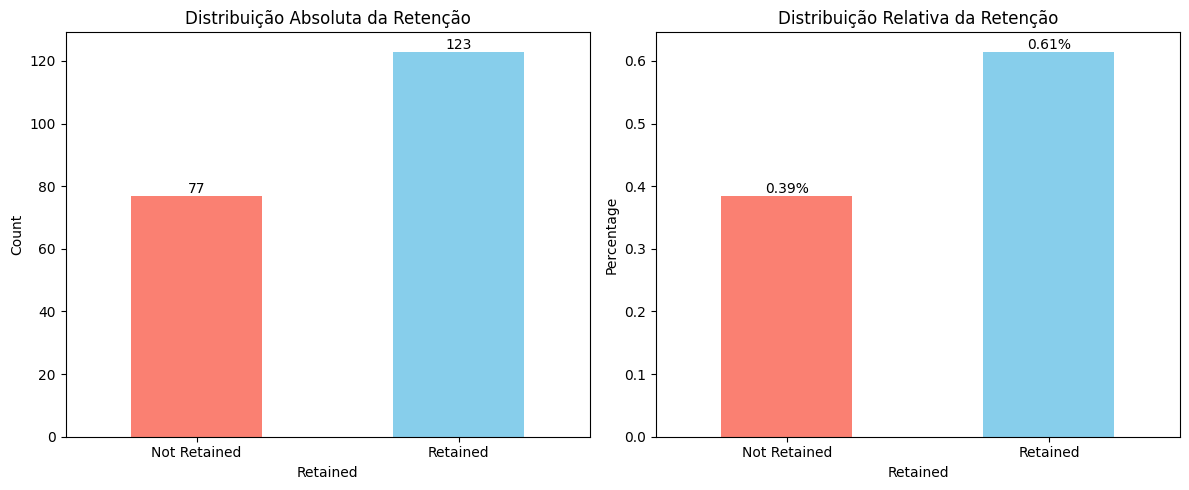

In [9]:
# Verificar a distribuição da variável alvo absoluta e relativa

# Definir os nomes para os rótulos
df_retained_cat = df_raw.copy()
df_retained_cat['Retained'] = df_retained_cat['Retained'].map({0:'Not Retained', 1:'Retained'})

# Tamanho do gráfico
plt.figure(figsize=(12, 5))

# Gráfico 1: Freq. Absoluta
plt.subplot(1, 2, 1)
ax1 = df_retained_cat['Retained'].value_counts().sort_index().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Distribuição Absoluta da Retenção')
plt.xticks(rotation=0)
plt.ylabel('Count')
ax1.bar_label(ax1.containers[0])

# Gráfico 2: Freq. Relativa
plt.subplot(1, 2, 2)
ax2 = df_retained_cat['Retained'].value_counts(normalize=True).sort_index().plot(kind='bar', color=['salmon', 'skyblue'])
plt.title('Distribuição Relativa da Retenção')
plt.xticks(rotation=0)
plt.ylabel('Percentage')
ax2.bar_label(ax2.containers[0], fmt='%.2f%%')

plt.tight_layout()
plt.savefig(FIGURES_UNDERSTANDING_DIR / "distribuicao_retencao_absoluta_relativa.png", bbox_inches="tight")
plt.show()

#### **Interpretação:**

- O gráfico de barras mostra a distribuição da target. Observa-se uma ligeira maioria de estagiários retidos (61%), o que confirma o leve desbalanceamento identificado anteriormente.
- Esta distribuição justifica a escolha de métricas como **Recall da classe 0** (prioridade de negócio) e **F2-Score** (equilíbrio com peso no Recall).

## Variáveis numéricas

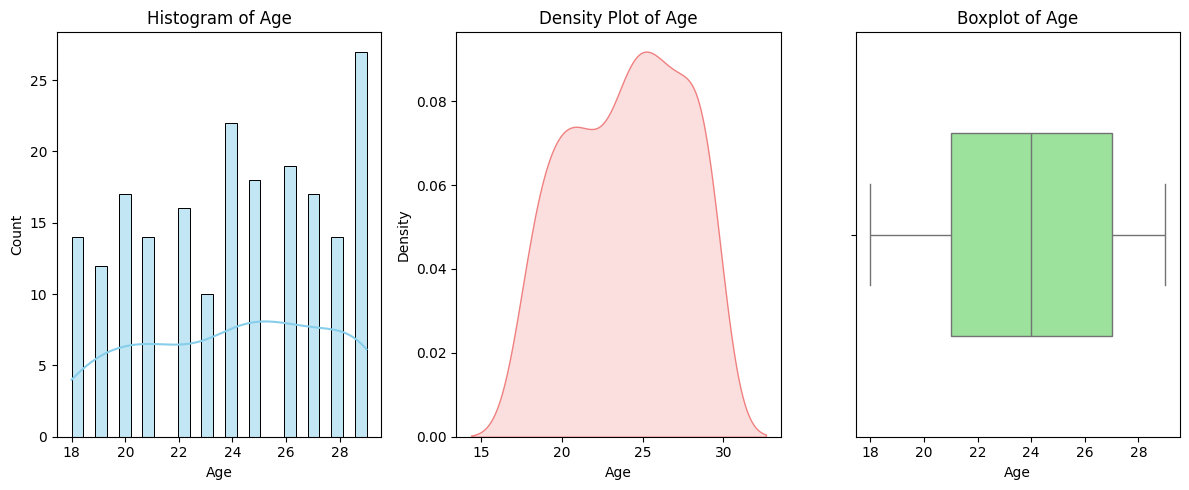

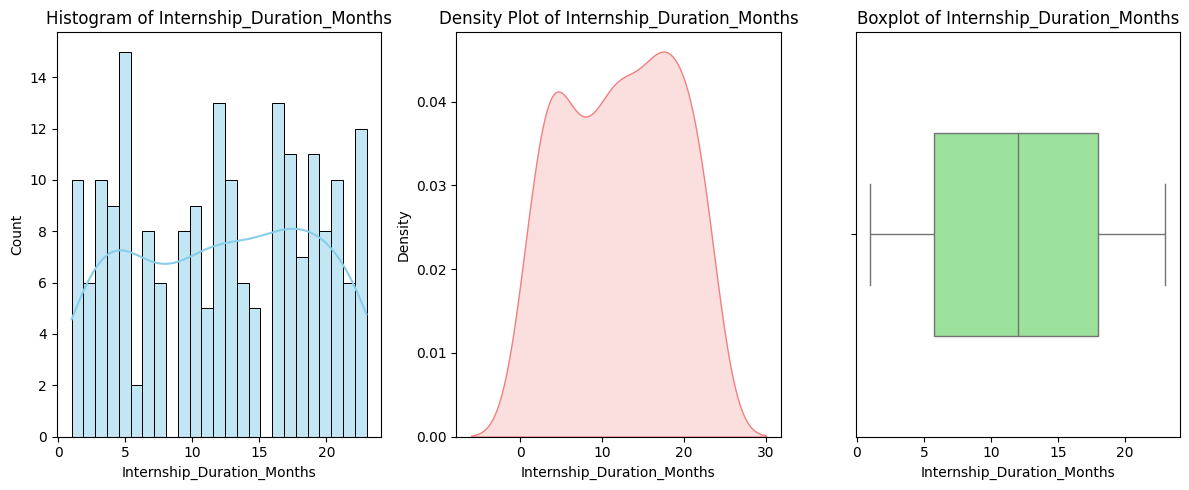

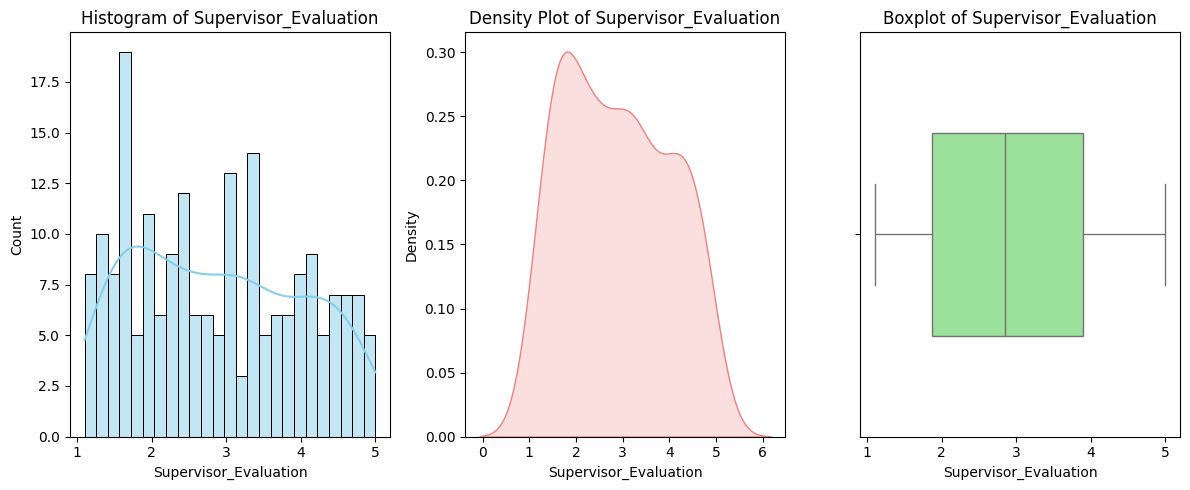

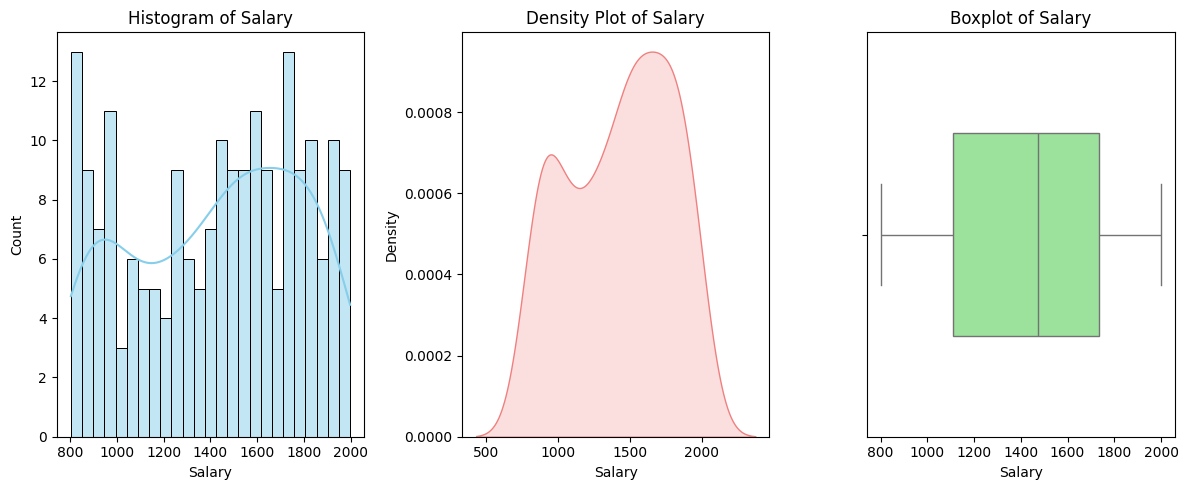

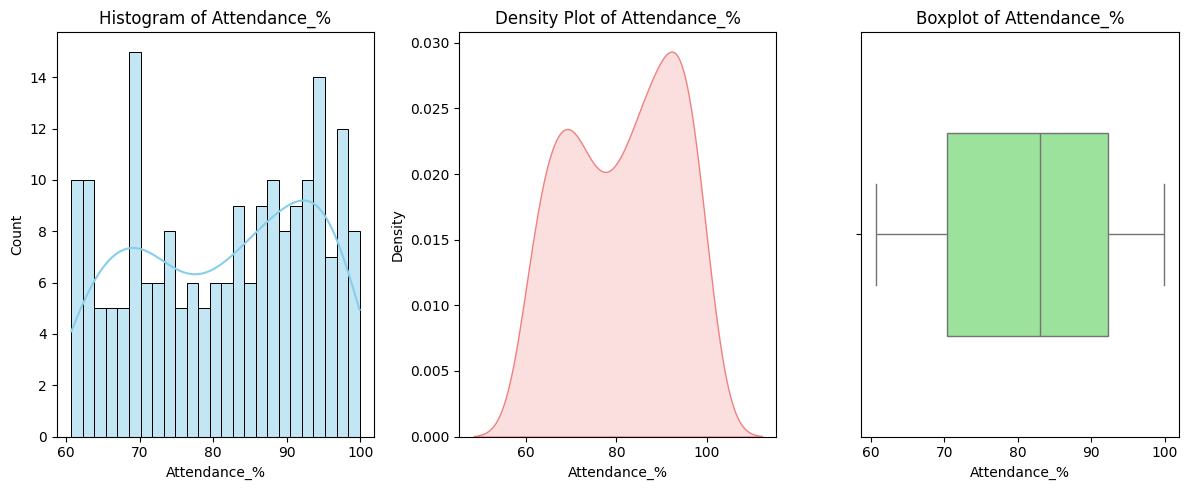

In [10]:
# Colunas numéricas
colunas_numericas = df_raw.select_dtypes(include=['int64', 'float64']).drop(["Intern_ID", 'Retained'], axis=1).columns

# Análise univariada para colunas numéricas
for coluna in colunas_numericas:
    plt.figure(figsize=(12, 5))
    
    # Histograma
    plt.subplot(1, 3, 1)
    sns.histplot(data=df_raw, x=coluna, bins=25, kde=True, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {coluna}')
    
    # Distribuição de densidade
    plt.subplot(1, 3, 2)
    sns.kdeplot(df_raw[coluna], color='lightcoral', fill=True)
    plt.title(f'Density Plot of {coluna}')
    
    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(x=df_raw[coluna], color='lightgreen', showfliers=True, width=0.5)
    # Para colocarmos incrementos de 1 em 1 no eixo x, podemos usar o plt.xticks() para definir os ticks do eixo x
    plt.title(f'Boxplot of {coluna}')
    
    plt.tight_layout()
    plt.savefig(FIGURES_UNDERSTANDING_DIR / f"analise_univariada_features_numericas_grafico_{coluna}.png", bbox_inches="tight")
    plt.show()

#### **Interpretação:**

- `Age`: Distribuição com ligeiro enviesamento à esquerda (concentração em idades mais avançadas no intervalo); o pico de frequência ocorre aos 29 anos, com mediana próxima dos 24.

- `Internship_Duration_Months`: Distribuição bimodal com picos nos 5 e 18 meses; a dispersão é ampla (1 a 23 meses), com uma mediana centralizada em torno dos 12 meses.

- `Supervisor_Evaluation`: Distribuição multimodal com maior concentração no limite inferior (aprox. 1.5 a 2.0); a mediana situa-se em torno de 2.9, indicando avaliações predominantemente moderadas a baixas.

- `Salary`: Distribuição relativamente uniforme com um leve viés à direita (salários mais altos); a mediana ronda os 1500, sem presença de outliers visíveis.

- `Attendance_%`: Apresenta uma tendência bimodal, com picos de frequência em cerca de 70% e 95%; a maioria dos dados concentra-se acima dos 80%, sugerindo boa assiduidade geral.

    *Nota*: A variável Intern_ID foi desconsiderada.

## Variáveis categóricas

C:\Users\Pedro\AppData\Local\Temp\ipykernel_23968\652667486.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x=coluna, order=df_raw[coluna].value_counts().index, palette='pastel')


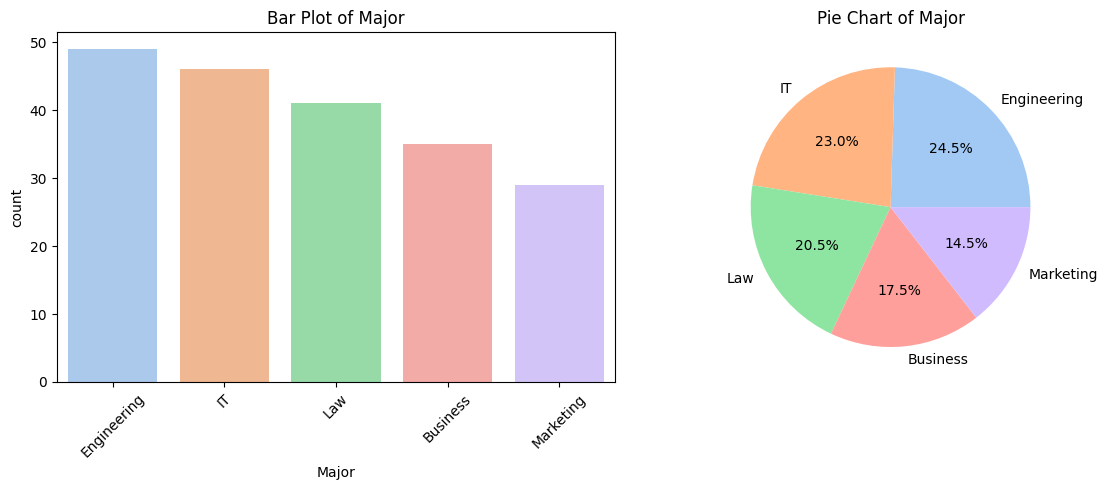

C:\Users\Pedro\AppData\Local\Temp\ipykernel_23968\652667486.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x=coluna, order=df_raw[coluna].value_counts().index, palette='pastel')


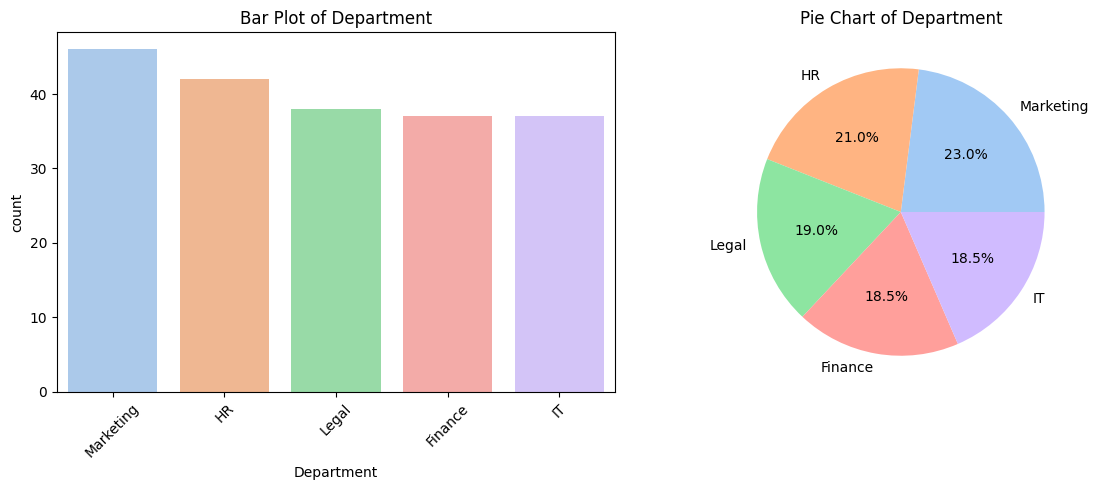

In [11]:
# Colunas categóricas
colunas_categoricas = df_raw.select_dtypes(include=['object']).columns

for coluna in colunas_categoricas:
    plt.figure(figsize=(12, 5))
    
    # Gráfico de barras (Seaborn)
    plt.subplot(1, 2, 1)
    sns.countplot(data=df_raw, x=coluna, order=df_raw[coluna].value_counts().index, palette='pastel')
    plt.title(f'Bar Plot of {coluna}')
    plt.xticks(rotation=45)
    
    # Gráfico de pie (Matplotlib)
    plt.subplot(1, 2, 2)
    df_raw[coluna].value_counts().plot(
        kind='pie',
        autopct='%1.1f%%',
        colors=sns.color_palette('pastel')
    )
    plt.title(f'Pie Chart of {coluna}')
    plt.ylabel('')
    
    plt.tight_layout()
    plt.savefig(FIGURES_UNDERSTANDING_DIR / f"analise_univariada_features_categoricas_grafico_{coluna}.png", bbox_inches="tight")
    plt.show()

#### **Interpretação:**

- `Major`: Variável categórica que identifica a área académica, sendo Engineering a classe dominante (24,5%).

- `Department`: Variável categórica que define a alocação funcional, liderada pelo departamento de Marketing (23%).

- Ambas apresentam categorias equilibradas, sem dominância extrema. (Esta característica facilita o One-Hot encoding, uma vez que cada coluna dummy gerada terá variância suficiente (nem sempre 0 nem sempre 1), contribuindo de forma útil e informativa para o modelo, evitando a criação de variáveis quase constantes ou redundantes.)

<hr>

## 2. **Análise bivarida**
<hr>

Nesta etapa analisamos as relações entre pares de variáveis, com foco especial na variável target `Retained`.

C:\Users\Pedro\AppData\Local\Temp\ipykernel_23968\2519544853.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_raw, x='Retained', y=var, palette='Set1', inner="quartile")


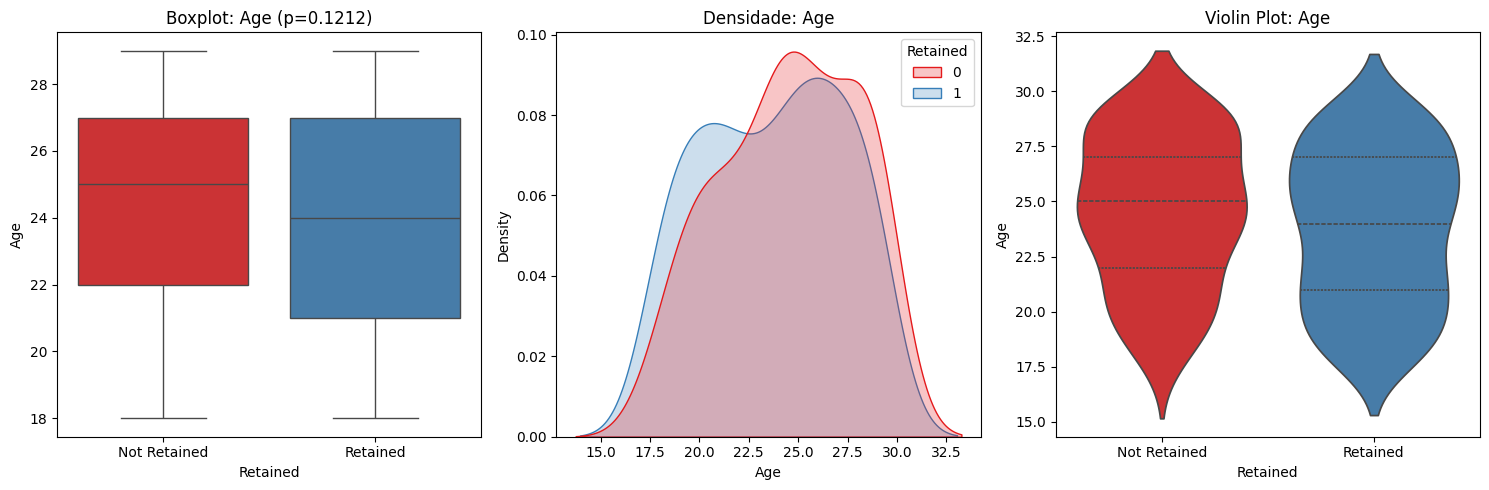

❌ Sem diferença estatisticamente significativa para Age.



C:\Users\Pedro\AppData\Local\Temp\ipykernel_23968\2519544853.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_raw, x='Retained', y=var, palette='Set1', inner="quartile")


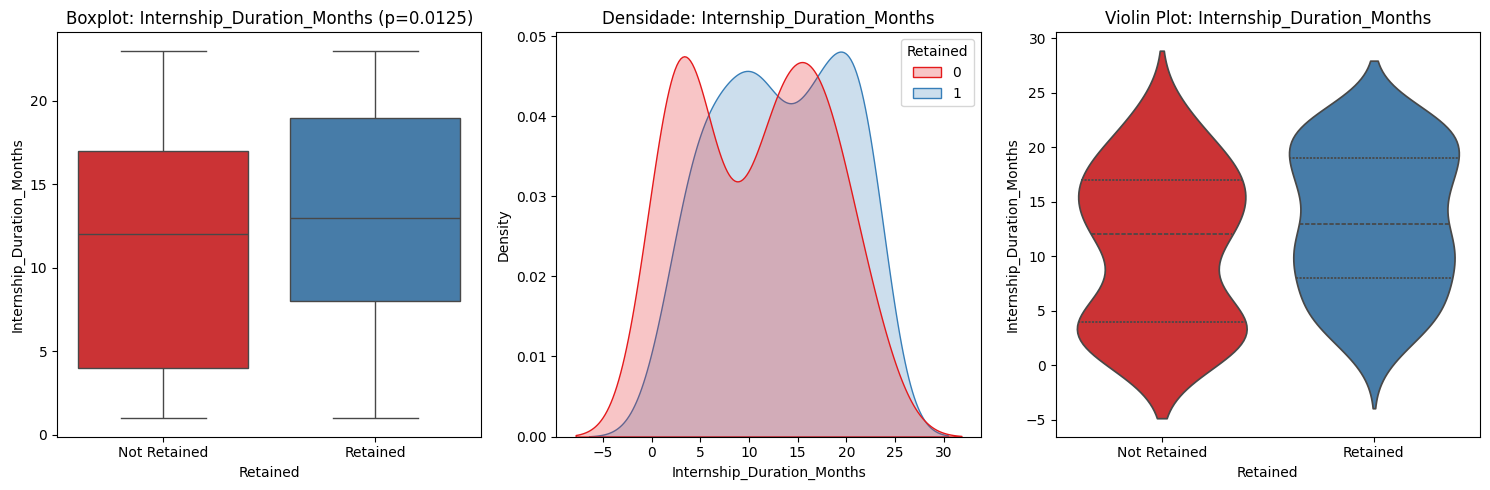

✅ Diferença estatisticamente significativa para Internship_Duration_Months.



C:\Users\Pedro\AppData\Local\Temp\ipykernel_23968\2519544853.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_raw, x='Retained', y=var, palette='Set1', inner="quartile")


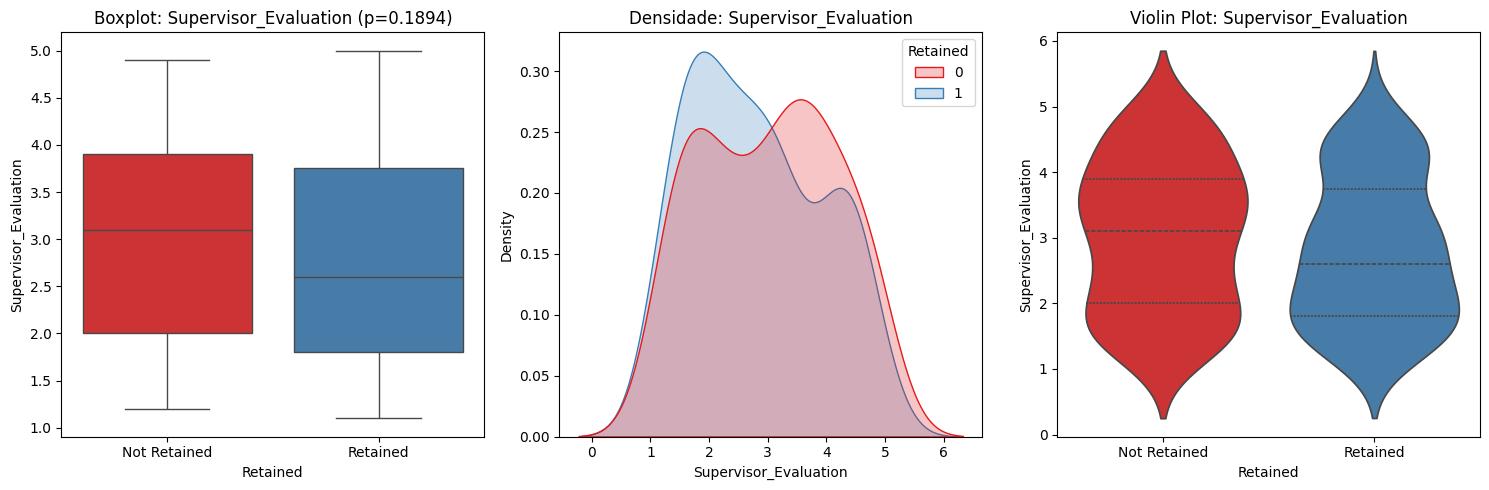

❌ Sem diferença estatisticamente significativa para Supervisor_Evaluation.



C:\Users\Pedro\AppData\Local\Temp\ipykernel_23968\2519544853.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_raw, x='Retained', y=var, palette='Set1', inner="quartile")


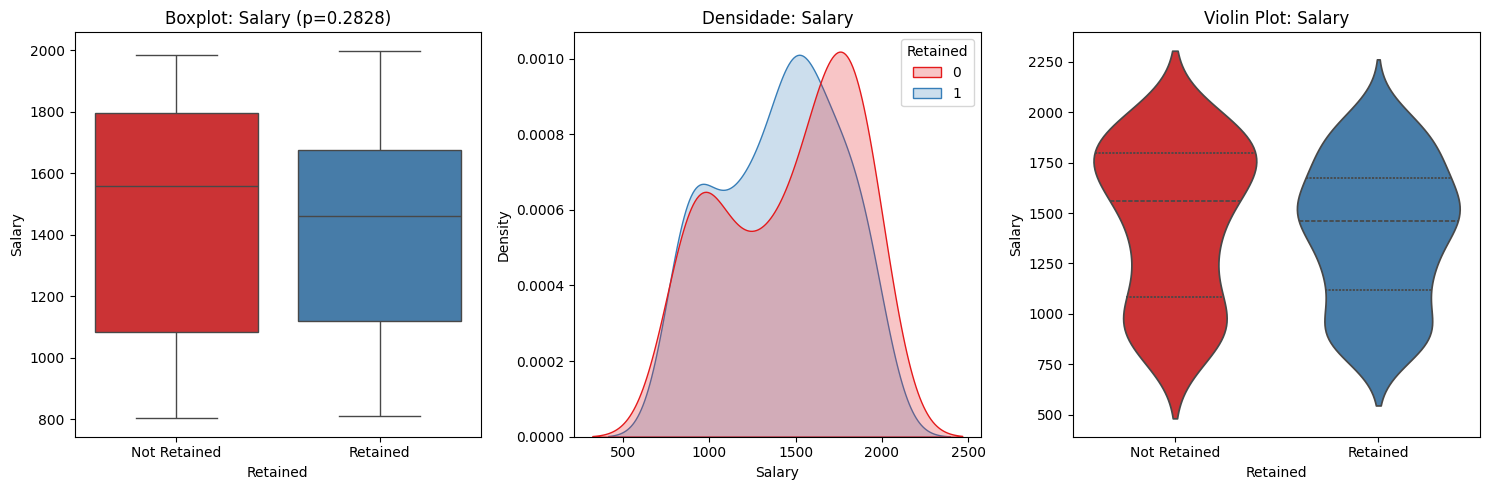

❌ Sem diferença estatisticamente significativa para Salary.



C:\Users\Pedro\AppData\Local\Temp\ipykernel_23968\2519544853.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_raw, x='Retained', y=var, palette='Set1', inner="quartile")


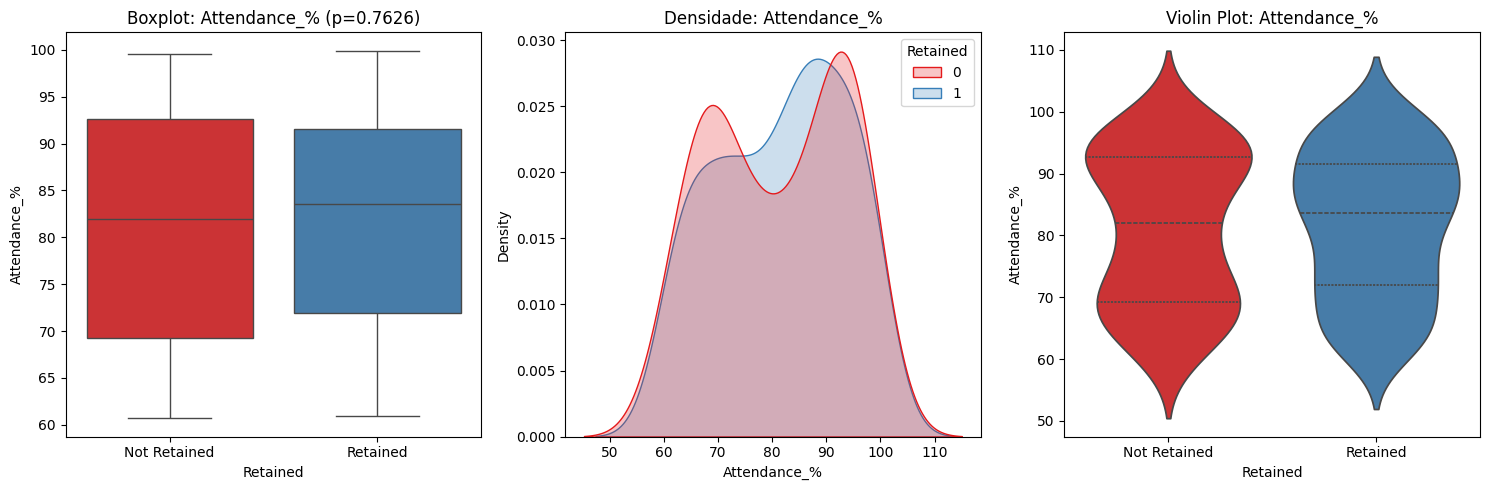

❌ Sem diferença estatisticamente significativa para Attendance_%.



In [12]:
from scipy.stats import ttest_ind

labels = ['Not Retained', 'Retained']

for var in colunas_numericas:
    if var == "Retained":
        continue

    # 1. Separar grupos e calcular t-test
    group0 = df_raw[df_raw['Retained'] == 0][var]
    group1 = df_raw[df_raw['Retained'] == 1][var]
    t_stat, p = ttest_ind(group0, group1)

   # Criar uma única figura com dois espaços (1 linha, 2 colunas)
    plt.figure(figsize=(15, 5))

    # 2. Boxplot
    plt.subplot(1, 3, 1)
    sns.boxplot(data=df_raw, x='Retained', y=var, hue='Retained', palette='Set1', legend=False)
    plt.xticks(ticks=[0, 1], labels=labels)
    plt.title(f'Boxplot: {var} (p={p:.4f})')

    # 3. KDE Plot
    plt.subplot(1, 3, 2)
    sns.kdeplot(data=df_raw, x=var, hue='Retained', palette='Set1', fill=True, common_norm=False)
    plt.title(f'Densidade: {var}')

    # 4. Violin Plot
    plt.subplot(1, 3, 3)
    sns.violinplot(data=df_raw, x='Retained', y=var, palette='Set1', inner="quartile")
    plt.xticks(ticks=[0, 1], labels=labels)
    plt.title(f'Violin Plot: {var}')

    plt.tight_layout()
    plt.savefig(FIGURES_UNDERSTANDING_DIR / f"analise_bivariada_numericas_vs_target_grafico_{var}.png", bbox_inches="tight")
    plt.show()

    if p < 0.05:
        print(f"✅ Diferença estatisticamente significativa para {var}.\n")
    else:
        print(f"❌ Sem diferença estatisticamente significativa para {var}.\n")


#### **Interpretação:**

- `Age`: Não existe associação significativa (p≈0.12); a distribuição etária é quase idêntica entre os grupos retidos e não retidos.

- `Internship_Duration_Months`: Variável com impacto real (p≈0.01); estágios mais longos tendem a ter maior probabilidade de retenção.

- `Supervisor_Evaluation`: Sem efeito estatístico relevante (p≈0.19); boas avaliações distribuem-se de forma semelhante em ambos os grupos de retenção.

- `Salary`: O salário não é um fator diferenciador na retenção (p≈0.28); as medianas salariais são equiparáveis para quem fica e quem sai.

- `Attendance_%`: A assiduidade não diferencia a retenção (p≈0.76); ambos os grupos apresentam comportamentos de presença muito similares.

## Variáveis categóricas vs Variável target + Teste de Inferência Estatística (Qui-quadrado)

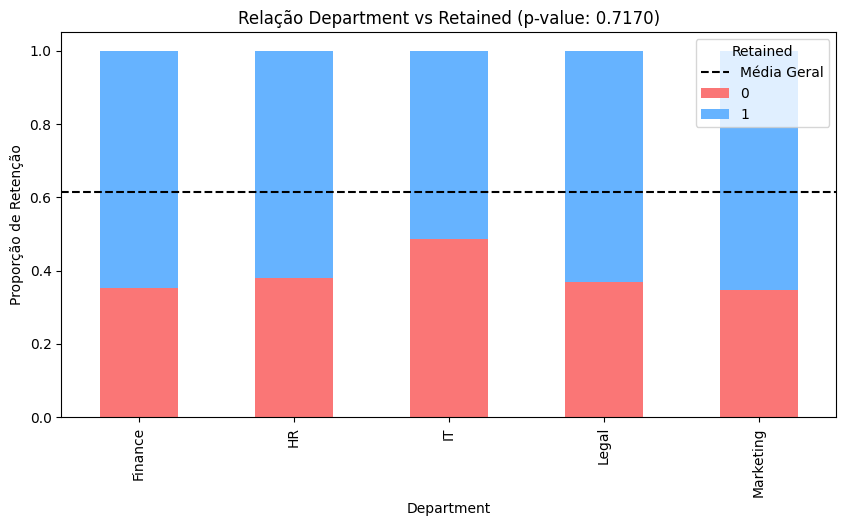

⚠️ A variável Department não parece influenciar a retenção isoladamente.


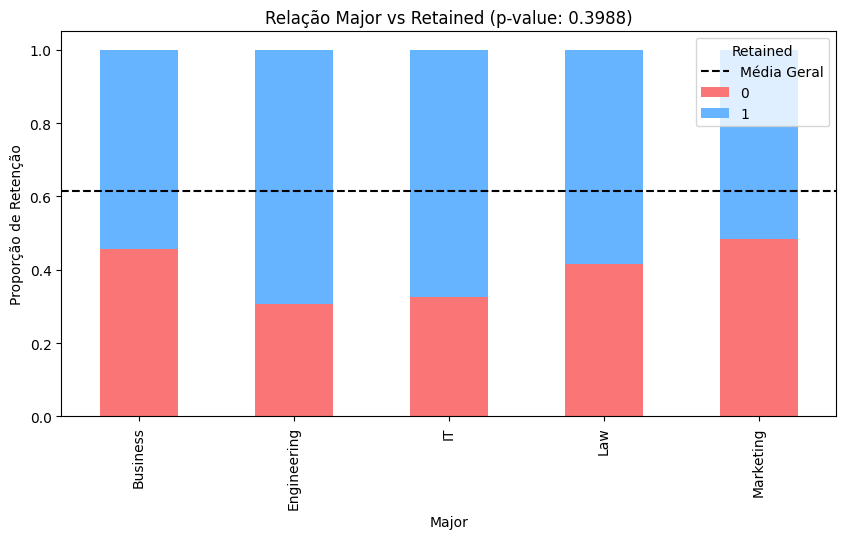

⚠️ A variável Major não parece influenciar a retenção isoladamente.


In [13]:
from scipy.stats import chi2_contingency

categorical_vars = ['Department', 'Major']

for var in categorical_vars:
    # 1. Tabela de Contingência
    contingency = pd.crosstab(df_raw[var], df_raw['Retained'])
    
    # 2. Teste Qui-Quadrado
    chi2, p, dof, ex = chi2_contingency(contingency)
    
    # 3. Visualização: Stacked Bar 100%
    contingency_pct = contingency.div(contingency.sum(1), axis=0)
    contingency_pct.plot(kind='bar', stacked=True, figsize=(10, 5), color=["#fa7676",'#66b3ff'])
    
    plt.title(f'Relação {var} vs Retained (p-value: {p:.4f})')
    plt.ylabel('Proporção de Retenção')
    plt.axhline(df_raw['Retained'].mean(), color='black', linestyle='--', label='Média Geral')
    plt.legend(title='Retained', loc='upper right')
    
    plt.savefig(FIGURES_UNDERSTANDING_DIR / f"analise_bivariada_categoricas_vs_target_chi2_{var}.png", bbox_inches="tight")

    plt.show()

    # Opinião técnica: se p < 0.05, a variável é um "driver" forte.
    if p < 0.05:
        print(f"✅ A variável {var} tem associação significativa com a retenção.")
    else:
        print(f"⚠️ A variável {var} não parece influenciar a retenção isoladamente.")

#### **Interpretação:**

- `Department`: A variável não apresenta associação significativa com a retenção (p=0.71); a proporção de funcionários que permanecem é consistente entre todos os departamentos.

- `Major`: A área de formação não discrimina o desfecho de retenção (p=0.39); as variações observadas entre cursos (como Engineering vs Marketing) situam-se dentro da margem de flutuação aleatória.

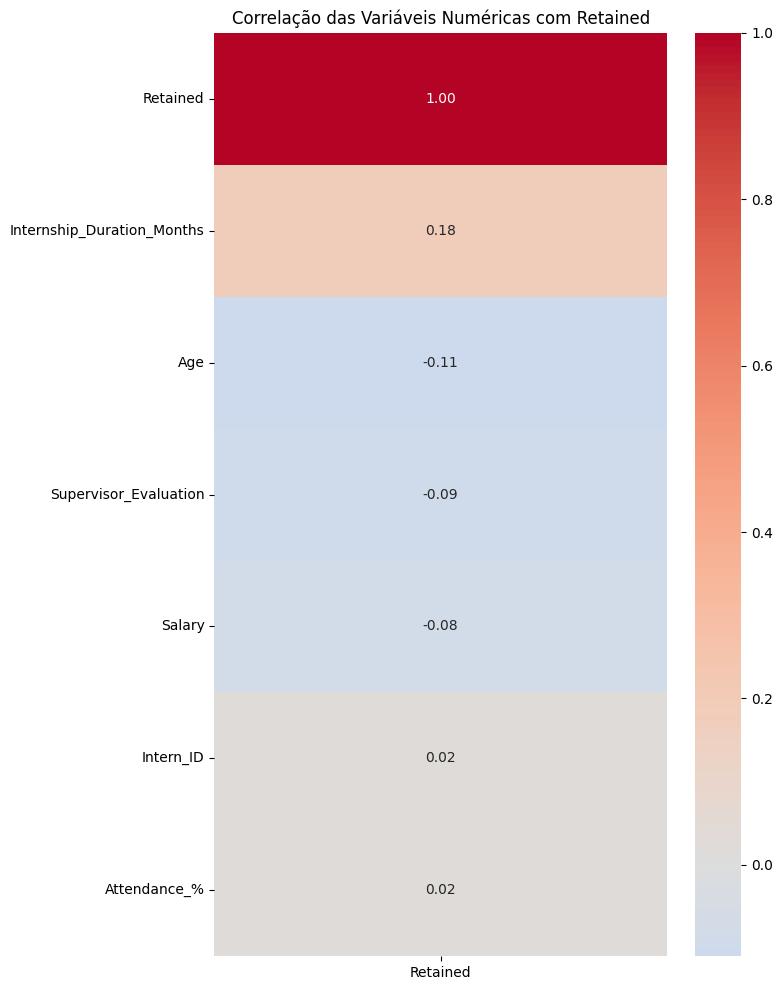

In [14]:
# Selecionar apenas colunas numéricas
df_num = df_raw.select_dtypes(include='number')

# Calcular correlação das variáveis numéricas com a target
corr_matrix = df_num.corr()[['Retained']]

# Criar coluna auxiliar com valor absoluto para ordenar
corr_matrix['abs_corr'] = corr_matrix['Retained'].abs()

# Ordenar do mais forte para o mais fraco
corr_sorted = corr_matrix.sort_values(by='abs_corr', ascending=False).drop('abs_corr', axis=1)

# Plot
plt.figure(figsize=(8, 10))
sns.heatmap(corr_sorted, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlação das Variáveis Numéricas com Retained')

plt.tight_layout()
plt.savefig(FIGURES_UNDERSTANDING_DIR / "correlacao_variaveis_numericas_retained.png", bbox_inches="tight")
plt.show()

#### **Interpretação:**

- `Internship_Duration_Months`: Apresenta a maior correlação com a retenção (r≈0.18), embora ainda fraca; sugere que estágios mais longos estão ligeiramente associados a maior probabilidade de retenção (alinhada com conclusões anteriores).

- `Age`: Correlação negativa muito fraca (r≈-0.11), indicando que a idade não tem influência relevante na retenção.

- `Supervisor_Evaluation`: Relação praticamente inexistente (r≈-0.09); as avaliações do supervisor não diferenciam claramente os grupos.

- `Salary`: Correlação muito baixa (r≈-0.08), sugerindo que o salário não é um fator determinante para a retenção.

- `Intern_ID`: Correlação residual (r≈0.02), sem qualquer significado analítico (variável identificadora).

<hr>

## 3. **Análise multivariada**
<hr>


## Fase 1 - Correlação entre variáveis (Multicolinearidade)

**Objetivo:**  
Diagnosticar a existência de **multicolinearidade** entre as variáveis preditoras independentes (X vs. X).

A multicolinearidade ocorre quando duas ou mais variáveis explicam praticamente a mesma informação, o que pode:  
- distorcer os coeficientes dos modelos estatísticos,  
- inflar artificialmente a importância de algumas variáveis,  
- dificultar a interpretação da contribuição individual de cada preditor.

**Nota importante:**  
A multicolinearidade é um problema que se verifica **exclusivamente entre as variáveis independentes** (features).  
A força da relação de uma variável com a variável alvo (`Retained`) mede a **relevância preditiva** dessa variável, e não multicolinearidade.
<hr>

### Correlação entre **variáveis numéricas** (Multicolinearidade)

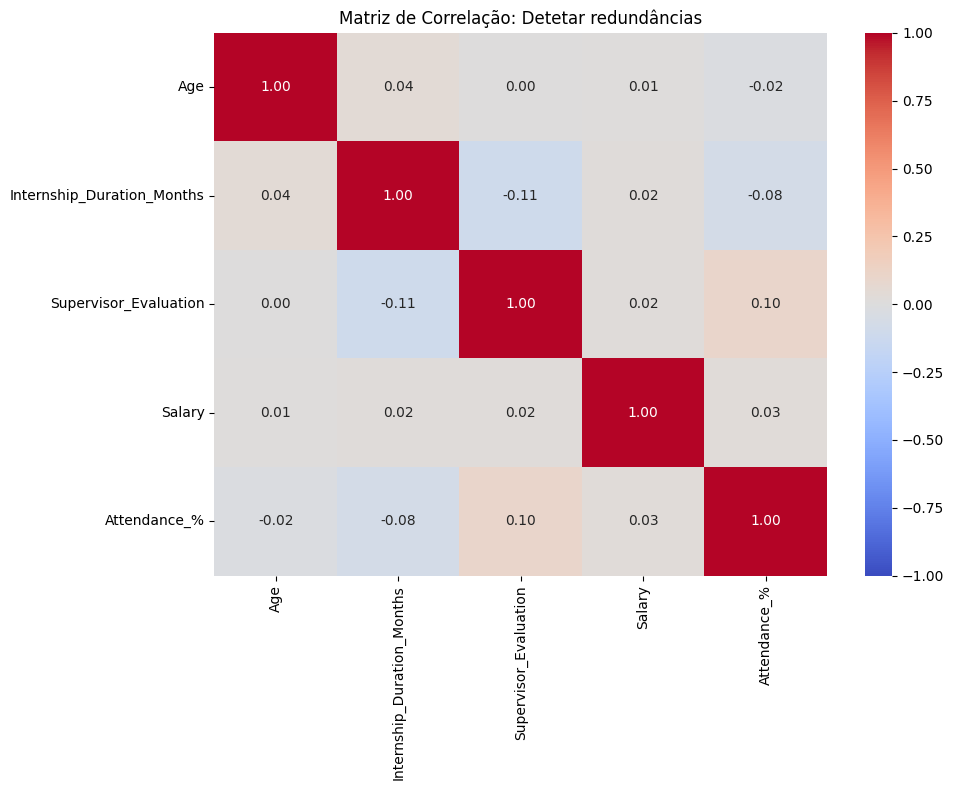

In [15]:
plt.figure(figsize=(10, 8))
# Selecionamos apenas as numéricas para a correlação de Pearson
sns.heatmap(df_raw[colunas_numericas].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação: Detetar redundâncias')

plt.tight_layout()
plt.savefig(FIGURES_UNDERSTANDING_DIR / "matriz_correlacao_detetar_redundancias.png", bbox_inches="tight")
plt.show()

#### **Interpretação:**

- Todas as correlações entre as variáveis numéricas são **muito fracas** ( |r| ≤ 0.11 na maioria dos casos).
- A maior correlação observada é negativa entre `Internship_Duration_Months` e `Supervisor_Evaluation` (r ≈ -0.11), mas ainda assim insignificante do ponto de vista prático.
- **Não existe multicolinearidade** entre as variáveis, não havendo necessidade de eliminar variáveis por redundância nesta fase.
- Não há redundância nos dados sendo que cada uma trará uma informação única para o modelo.
- As variáveis são independentes.


**Implicação prática para as próximas fases:**
- Manter todas as variáveis numéricas (sem remoção por multicolinearidade).
- Explorar relações **não-lineares** e **interações**

### Correlação entre **variáveis categóricas** (Multicolinearidade)

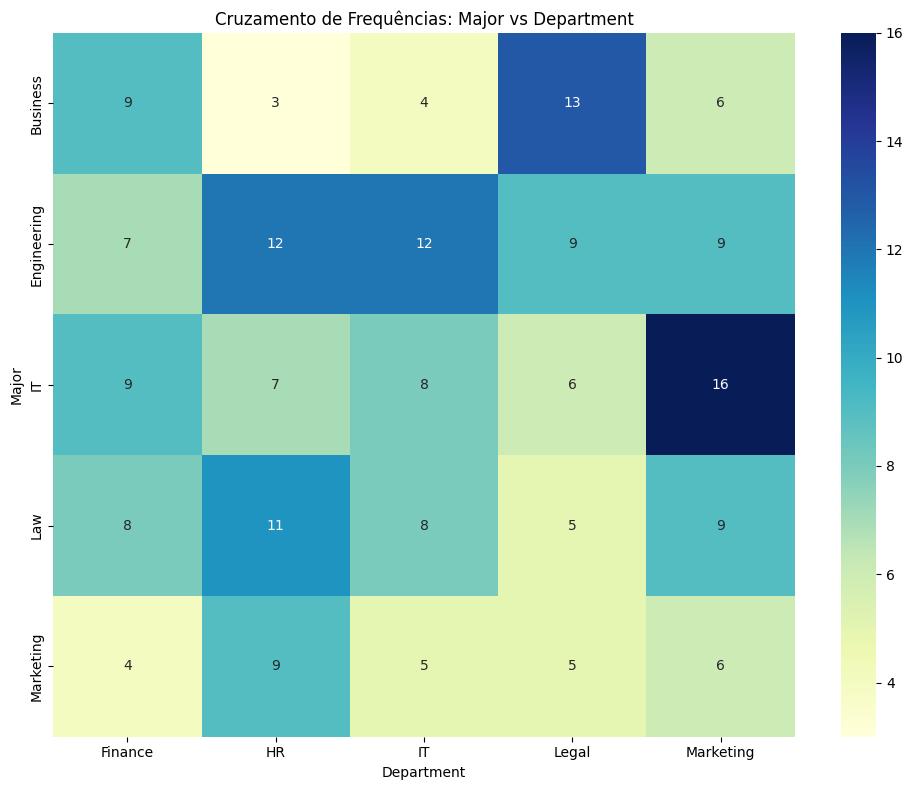

In [16]:
# Criar a tabela de frequências (Contingência)
ct = pd.crosstab(df_raw['Major'], df_raw['Department'])

plt.figure(figsize=(10, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Cruzamento de Frequências: Major vs Department')

plt.tight_layout()
plt.savefig(FIGURES_UNDERSTANDING_DIR / "analise_multicolinearidade_categoricas_major_vs_department.png", bbox_inches="tight")
plt.show()

In [17]:
## teste de independência Qui-Quadrado
chi2, p, dof, ex = chi2_contingency(ct)
print(f"P-value da associação Major/Dept: {p:.2f}")

P-value da associação Major/Dept: 0.17


#### Interpretação do Cruzamento Major vs Department e do Teste de Independência:

O heatmap apresenta a distribuição conjunta das observações entre as variáveis categóricas `Major` e `Department`, com as células a indicar o número absoluto de estagiários em cada combinação.
Em complemento, foi realizado o **teste Qui-quadrado de independência** para avaliar se existe associação estatística significativa entre as duas variáveis.


**Principais concentrações observadas no heatmap:**
- A combinação mais frequente do dataset é **IT × Legal** (16 observações).
- **Engineering** tem presença forte em **HR** (12) e **IT** (12).
- **Law** destaca-se em **HR** (11).
- **Business** concentra-se mais em **Legal** (13) e **Marketing** (6).

**Resultados do teste Qui-quadrado:**
- p-value = **0.17** (> 0.05)

**Conclusão estatística:**  
Como o p-value é superior a 0.05, **não existe evidência estatística significativa** de que o curso (`Major`) e o departamento de colocação (`Department`) estejam associados de forma sistemática.

**Interpretação integrada:**
Embora o heatmap mostre algumas concentrações visuais (ex.: IT em Legal, Engineering em HR/IT, Business em Legal), estas oscilações não são suficientemente fortes para indicar uma dependência real entre as variáveis.

**Implicações para a modelação:**
- As variáveis `Major` e `Department` **não apresentam redundância significativa** entre si.
- Não há justificação estatística para eliminar nenhuma delas.
- Ambas devem ser mantidas na análise e na modelação.

<hr>

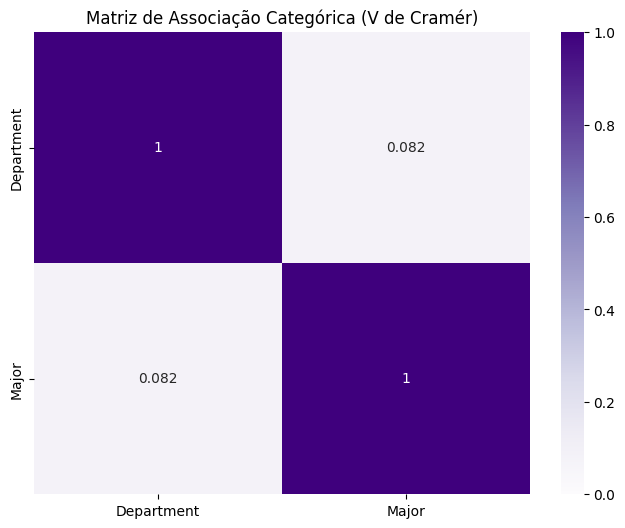

In [18]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correção de viés (Bias correction)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Selecionar variáveis categóricas
v_matrix = pd.DataFrame(index=categorical_vars, columns=categorical_vars)

for col1 in categorical_vars:
    for col2 in categorical_vars:
        v_matrix.loc[col1, col2] = cramers_v(df_raw[col1], df_raw[col2])

v_matrix = v_matrix.astype(float)

plt.figure(figsize=(8, 6))
sns.heatmap(v_matrix, annot=True, cmap='Purples', vmin=0, vmax=1)
plt.title("Matriz de Associação Categórica (V de Cramér)")

plt.savefig(FIGURES_UNDERSTANDING_DIR / "matriz_associacao_categorica_v_cramer.png", bbox_inches="tight")
plt.show()

> Nota: Embora o teste Qui-quadrado já tenha sido suficiente para concluir a independência (p = 0.17), calculámos também o V de Cramer como exercício complementar.


#### Interpretação da Matriz de Associação Categórica (V de Cramer)

A matriz apresenta o coeficiente **V de Cramer** entre `Department` e `Major`, com valor de **0.082**.

**Interpretação:**
- O valor de V de Cramer = 0.082 indica uma **associação extremamente fraca** (praticamente nula) entre as duas variáveis categóricas.

**Conclusão integrada:**
- Não há evidência de redundância ou multicolinearidade categórica entre estas features.
- Ambas as variáveis trazem informação distinta e devem ser utilizadas simultaneamente na modelação preditiva, sem risco de enviesamento ou inflação artificial da importância de uma sobre a outra.

<hr>

## Fase 2 - Segmentação e Interação

**Objetivo principal:**  
Identificar se o efeito de certas variáveis sobre a retenção (`Retained`) varia significativamente consoante o contexto ou subgrupo (interações e segmentação). O foco é detetar padrões não visíveis em análises isoladas (ex.: "a duração afeta a retenção de forma diferente por departamento" ou "os top performers saem mais em certos departamentos").

**Variáveis de referência e contexto analisadas:**
- Referência primária: `Internship_Duration_Months` (única com significância isolada p < 0.05  na análise bivariada)
- Interações exploradas: duração × departamento, duração × salário
- Segmentação adicional: fases do estágio (bins), top performers (avaliação ≥ Q3 e assiduidade ≥ Q3)
- Variáveis de contexto: `Department`, `Salary`, `Supervisor_Evaluation`, `Attendance_%` (embora não significativas isoladamente, podem revelar padrões relevantes quando cruzadas com a referência)

**Perguntas orientadoras:**
- A duração do estágio tem o mesmo impacto em todos os departamentos?
- Existe interação entre duração e salário na decisão de retenção?
- Estamos a perder os melhores estagiários (top performers) em departamentos específicos?
- A retenção varia de forma não linear ao longo das fases do estágio?

<hr>


#### Visão inicial bivariada: Pairplot das variáveis numéricas

Antes de mergulharmos em segmentações e interações específicas, vamos ter uma visão global rápida das relações entre as variáveis numéricas e a target `Retained`.

O gráfico abaixo mostra:
- Distribuições univariadas (diagonal)
- Relações bivariadas (scatterplots)
- Tudo colorido por `Retained`

Este pairplot ajuda a identificar visualmente padrões iniciais de separação ou sobreposição.

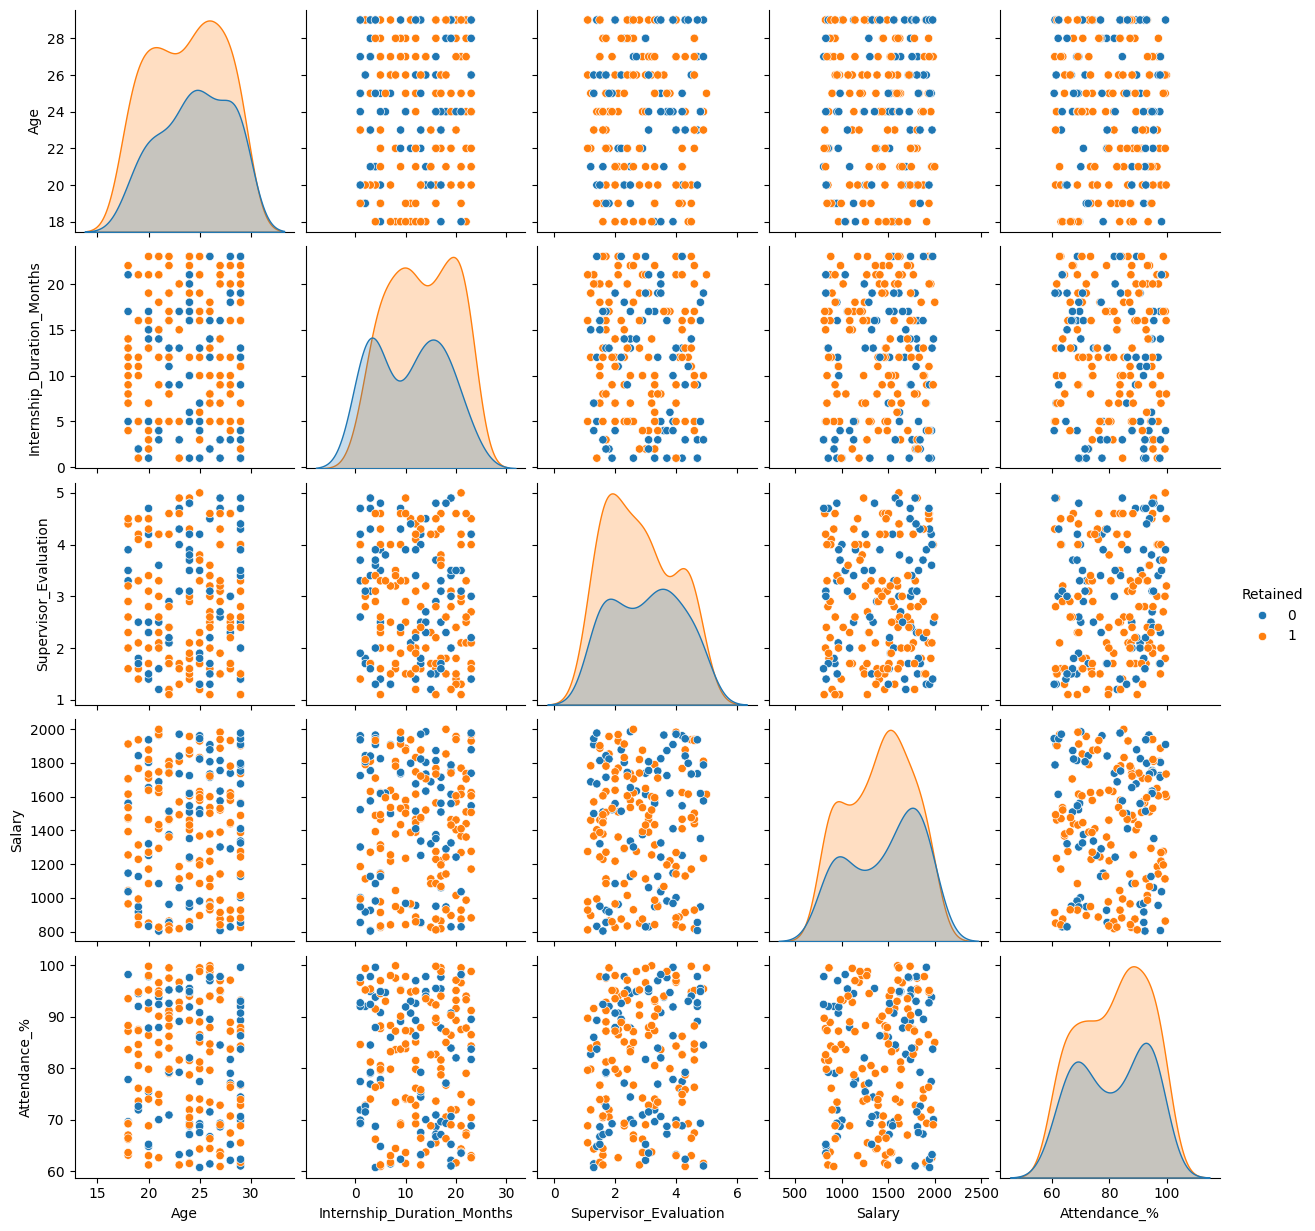

In [19]:
sns.pairplot(df_raw, vars=colunas_numericas, hue='Retained')

plt.savefig(FIGURES_UNDERSTANDING_DIR / "pairplot_numericas_vs_retained.png", bbox_inches="tight")
plt.show()

### Interpretação:

Há **muita sobreposição** entre as classes no pairplot, ou seja, nenhuma variável numérica ou par isolado separa claramente quem fica de quem sai.  
Vamos agora analisar interações específicas.

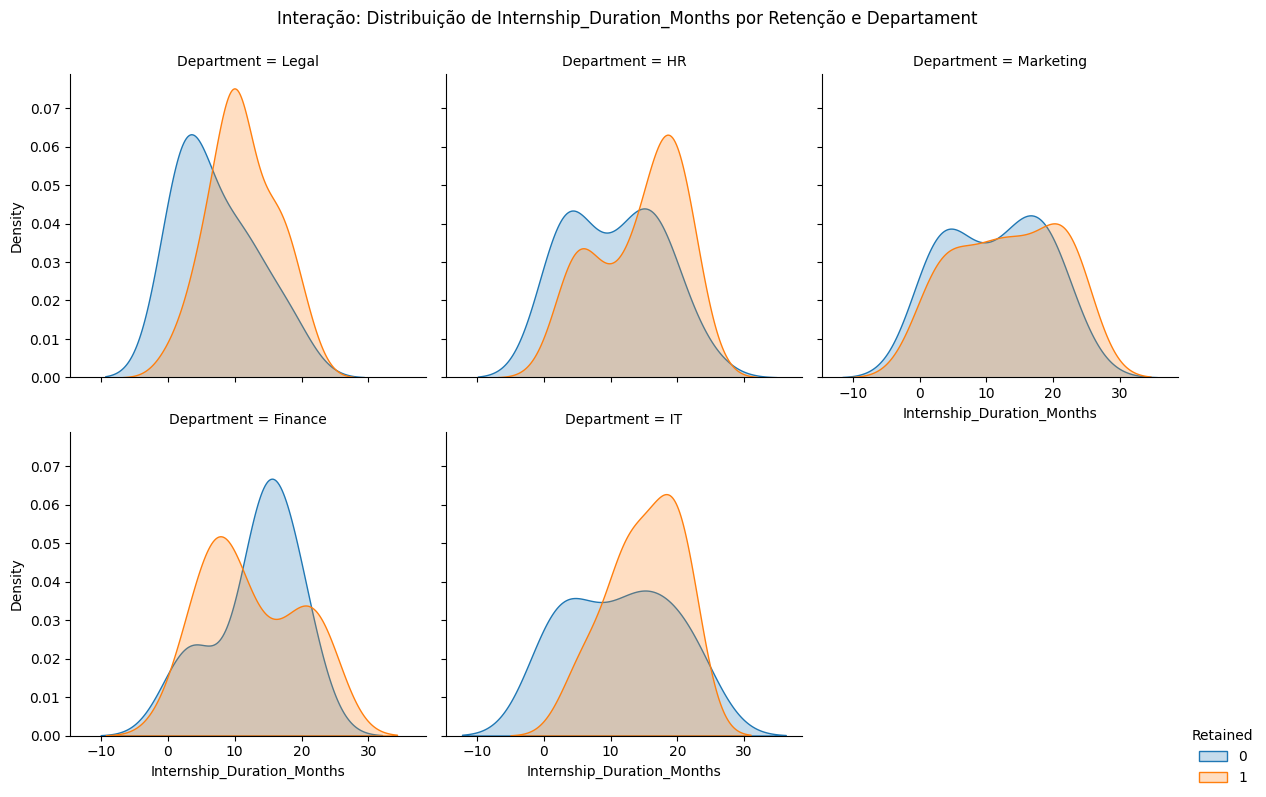

In [20]:
# Faceting (Fase 2 - Interação)

# Objetivo: Ver se a relação Internship_Duration_Months vs Retenção muda conforme o Departamento
g = sns.FacetGrid(df_raw, col="Department", hue="Retained", col_wrap=3, height=4)
g.map(sns.kdeplot, "Internship_Duration_Months", fill=True)
g.add_legend(loc='lower right')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Interação: Distribuição de Internship_Duration_Months por Retenção e Departament')

plt.savefig(FIGURES_UNDERSTANDING_DIR / "facetgrid_distribuicao_duracao_retencao_departamento.png", bbox_inches="tight")
plt.show()

### Interpretação – Interação: Duração do Estágio × Department × Retained

Os gráficos mostram a densidade de `Internship_Duration_Months` estratificada por `Department` e `Retained`.

**Padrões observados por departamento:**
- **Legal**: Separação mais clara — quem fica (laranja) tem estágios visivelmente mais longos (pico deslocado para a direita).
- **HR** e **Marketing**: Sobreposição quase total entre as curvas — duração do estágio não parece diferenciar retenção nestes departamentos.
- **Finance**: Separação muito moderada — quem fica tende a ter durações ligeiramente mais longas, mas menos pronunciada que em Legal.
- **IT**: Separação fraca — em alguns intervalos, quem sai tem durações mais longas.

**Conclusão:**
O efeito da duração do estágio na retenção **não é homogéneo** entre departamentos.  
É particularmente positivo em **Legal** (estágios longos associados a maior retenção), mas praticamente inexistente em **Marketing**.  


> Nota: Focamo-nos em `Department` porque representa o **ambiente de trabalho real** (mais próximo do contexto organizacional), ao contrário de `Major`, que reflete apenas o passado académico.

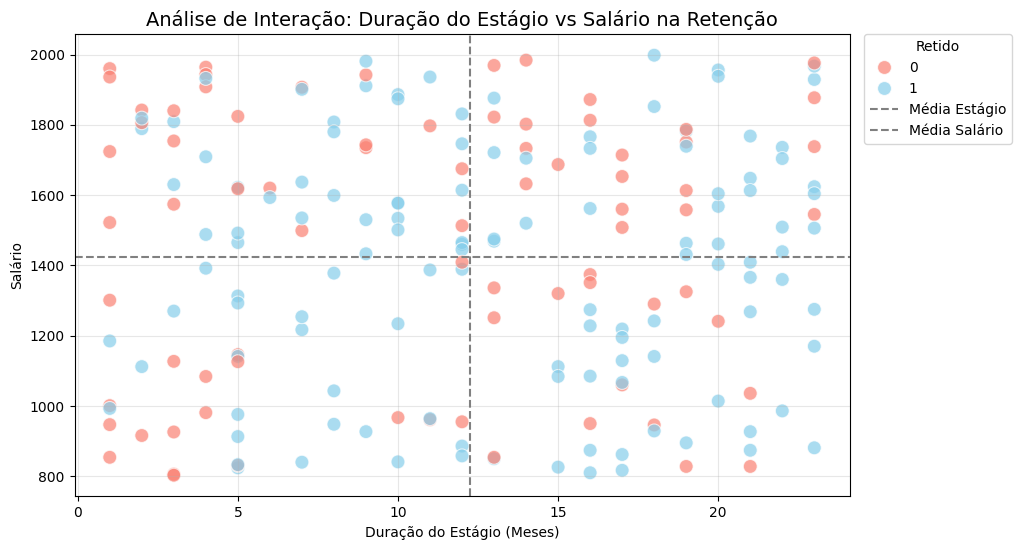

In [21]:
plt.figure(figsize=(10, 6))

# Criar Scatter Plot para ver a interação entre as duas variáveis vs Target
sns.scatterplot(
    data=df_raw, 
    x='Internship_Duration_Months', 
    y='Salary', 
    hue='Retained', 
    palette={0: 'salmon', 1: 'skyblue'}, 
    alpha=0.7, 
    s=100
)

# Adicionar linhas de média para criar quadrantes de análise
plt.axvline(df_raw['Internship_Duration_Months'].mean(), color='grey', linestyle='--', label='Média Estágio')
plt.axhline(df_raw['Salary'].mean(), color='grey', linestyle='--', label='Média Salário')

plt.title('Análise de Interação: Duração do Estágio vs Salário na Retenção', fontsize=14)
plt.xlabel('Duração do Estágio (Meses)')
plt.ylabel('Salário')
plt.legend(title='Retido', bbox_to_anchor=(1.01, 1.015), loc='upper left')
plt.grid(True, alpha=0.3)

plt.savefig(FIGURES_UNDERSTANDING_DIR / "scatter_duracao_vs_salario_retencao.png", bbox_inches="tight")
plt.show()

#### **Interpretação: Duração do Estágio vs Salário na Retenção**

O scatterplot mostra a relação conjunta entre `Internship_Duration_Months` e `Salary`, estratificada por `Retained`. As linhas tracejadas indicam as médias globais.

**Observações principais:**
- Distribuição relativamente homogénea das duas classes em quase todo o espaço (sem separação clara por quadrantes).
- Não surge um padrão evidente de interação: nem salários altos + duração longa protegem consistentemente a retenção, nem salários baixos + duração curta explicam saídas de forma dominante.
- A linha vertical (média de duração ≈ 12–13 meses) e horizontal (média salarial ≈ 1400) dividem o gráfico, mas as proporções de retenção são semelhantes nos quatro quadrantes.

**Conclusão:**
- Ausência de interação visual forte entre duração e salário na predição da retenção.
- O salário não atua como driver discriminante significativo (reforçado pelo p-valor ≈ 0.28 na análise bivariada isolada).
- Sugere que o salário é mais uma **variável de contexto** do que um fator causal direto da saída.
- Limitação: modelos lineares terão dificuldade em capturar efeitos; interações não-lineares ou outros fatores qualitativos (cultura, progressão de carreira) parecem mais determinantes.

**Insight organizacional:**  
Mesmo em níveis salariais elevados e estágios longos, observam-se saídas significativas, o que reforça a necessidade de olhar para drivers não financeiros (proposta de valor, alinhamento cultural, perspetivas de crescimento).

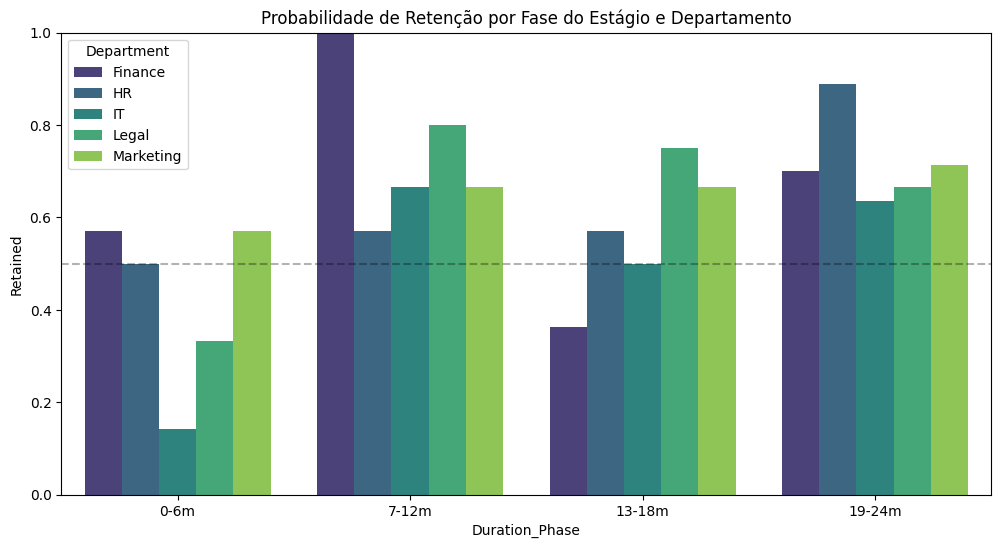

In [22]:
# 1. Criar variável temporária grupos de duração (bins), sem alterar df_raw
duration_phase = pd.cut(
    df_raw['Internship_Duration_Months'],
    bins=[0, 6, 12, 18, 24],
    labels=['0-6m', '7-12m', '13-18m', '19-24m']
)

# 2. Criar o resumo por fase e departamento
df_fases = (
    df_raw
    .assign(Duration_Phase=duration_phase)  # <- temporário
    .groupby(['Duration_Phase', 'Department'], observed=True)['Retained']
    .mean()
    .reset_index()
)

# 3. Visualizar de forma limpa (Gráfico de Barras)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_fases, x='Duration_Phase', y='Retained', hue='Department', palette='viridis')

plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)
plt.title('Probabilidade de Retenção por Fase do Estágio e Departamento')
plt.ylim(0, 1)

plt.savefig(FIGURES_UNDERSTANDING_DIR / "barplot_retencao_por_fase_e_departamento.png", bbox_inches="tight")
plt.show()

#### **Interpretação: Probabilidade de Retenção por Fase do Estágio e Departamento**

O gráfico de barras mostra a taxa de retenção (`Retained = 1`) estratificada por `Duration_Phase` (bins de 6 meses) e `Department`. Linha tracejada = média global (~61%).

**Padrões por departamento:**
- **Finance**: Pico extremo de 100% na fase 7–12 meses → sugere período de maior estabilidade/integração. Queda acentuada nas fases seguintes.
- **IT**: Taxa extremamente baixa (≈15%) nos estágios muito curtos (0–6 meses).
- **HR, Legal e Marketing**: Tendência geral positiva — retenção tende a melhorar à medida que o estágio avança. Valores frequentemente acima da média global na fase final (19–24 meses).

**Insights críticos:**
- A retenção **não é linear** ao longo do estágio: varia fortemente por departamento e fase.
- **Sinal de alerta em IT** nos primeiros 6 meses: possível desalinhamento entre expectativas, onboarding ou natureza do trabalho inicial.
- **Finance** destaca-se como departamento com maior volatilidade (pico perfeito intermédio, mas risco nas fases finais).
- Departamentos mais "estáveis" (Legal, HR, Marketing) beneficiam de estágios mais longos.

**Implicação para RH:**  
Intervenções precoces (0–6 meses) em IT e monitorização reforçada nas fases finais em Finance podem reduzir churn. O tempo de estágio ideal parece variar por departamento.

In [23]:
print(df_raw['Supervisor_Evaluation'].quantile(0.75))
print(df_raw['Attendance_%'].quantile(0.75))

3.9
92.325


C:\Users\Pedro\AppData\Local\Temp\ipykernel_23968\1828606345.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=high_performers, x='Department', y='Retained', palette='viridis', errorbar=None)


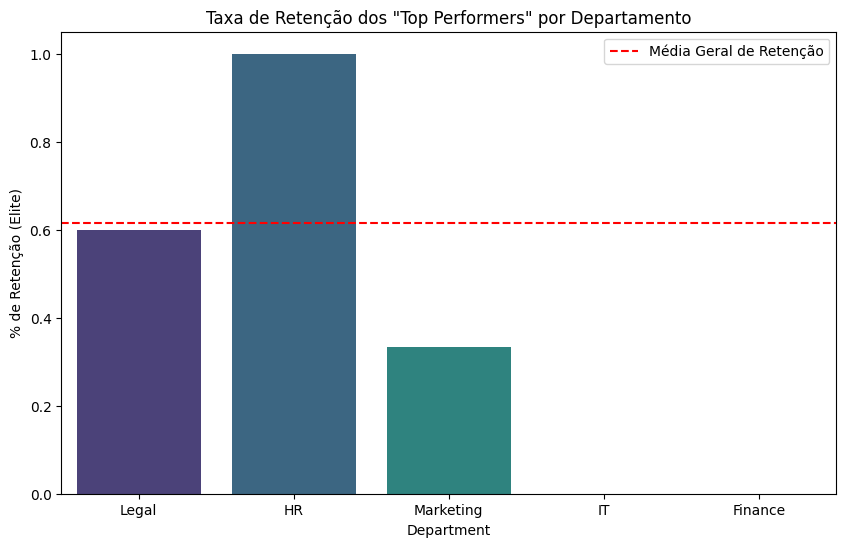

In [24]:
superior_evaluation = df_raw['Supervisor_Evaluation'].quantile(0.75)
attendance = df_raw['Attendance_%'].quantile(0.75)

# Filtrar apenas os estagiários de Alto Potencial
high_performers = df_raw[(df_raw['Supervisor_Evaluation'] >= superior_evaluation) & (df_raw['Attendance_%'] >= attendance)].copy()

plt.figure(figsize=(10, 6))
# Ver a média de retenção deste grupo específico por departamento
sns.barplot(data=high_performers, x='Department', y='Retained', palette='viridis', errorbar=None)

plt.axhline(df_raw['Retained'].mean(), color='red', linestyle='--', label='Média Geral de Retenção')
plt.title('Taxa de Retenção dos "Top Performers" por Departamento')
plt.ylabel('% de Retenção (Elite)')
plt.legend()

plt.savefig(FIGURES_UNDERSTANDING_DIR / "barplot_top_performers_retencao_por_departamento.png", bbox_inches="tight")
plt.show()

### **Interpretação: Retenção de Top Performers ("Elite") por Departamento**

Definição de "Top Performers" (elite): `Supervisor_Evaluation` ≥ Q3 e `Attendance_%` ≥ Q3.

O gráfico compara a taxa de retenção deste subgrupo por departamento com a média global (~61%).

**Observações principais:**
- **HR**: Retenção quase perfeita dos top performers (100%).
- **Legal**: Retenção razoável (≈60%), próxima da média global.
- **Marketing**: Retenção baixa (≈33%) — abaixo da média.
- **IT e Finance**: **0%** de retenção de elite (todos os top performers saíram).

**Insight crítico – "Estamos a perder os melhores?":**
- Sim, e de forma dramática em **IT e Finance**: departamentos onde os estagiários de elite apresentam churn total.
- Este padrão é alarmante porque ocorre **independentemente do desempenho interno** — reforça a gravidade do problema.

**Implicações estratégicas:**
- Forte indício de desalinhamento na proposta de valor para perfis de alto desempenho nestes departamentos.
- Possíveis causas: ofertas externas mais competitivas, falta de perspetivas claras de progressão, cultura organizacional inadequada.
- Prioridade organizacional: diagnosticar e intervir urgentemente em IT e Finance para reter talento de topo (ex.: mentoria reforçada, planos de carreira acelerados, ajustes salariais).

<br>
<br>
<hr>

# Diagnóstico de Complexidade (PCA)

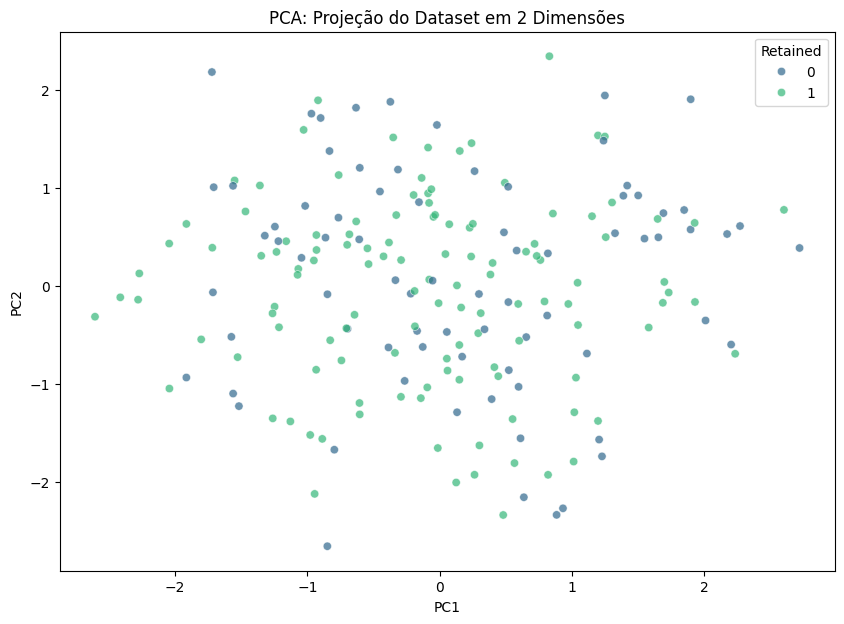

Variância explicada: 44.51%


In [25]:
# 1. Selecionar apenas colunas numéricas (excluindo a target para não "viciar" o PCA)
colunas_numericas_pca = df_raw.select_dtypes(include=['float64', 'int64']).columns
features_pca = [c for c in colunas_numericas_pca if c not in ['Intern_ID', 'Retained']]

# 2. Normalizar (obrigatório para PCA)
x = StandardScaler().fit_transform(df_raw[features_pca])

# 3. Aplicar PCA com 2 componentes (para visualização 2D)
pca = PCA(n_components=2)
components = pca.fit_transform(x)

# 4. Criar um DataFrame com os resultados
df_pca = pd.DataFrame(data = components, columns = ['PC1', 'PC2'])
df_pca['Retained'] = df_raw['Retained'].values # Adicionamos a target para colorir

# 5. Visualizar
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Retained', data=df_pca, palette='viridis', alpha=0.7)
plt.title('PCA: Projeção do Dataset em 2 Dimensões')

plt.savefig(FIGURES_UNDERSTANDING_DIR / "pca_projecao_2d_retencao.png", bbox_inches="tight")
plt.show()

# Extra: Ver quanta informação "sobreviveu" a esta compressão
print(f"Variância explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

## Análise dos Resultados PCA

**Variância explicada:**  
Os dois primeiros componentes principais capturam apenas **44.51%** da variância total do dataset.

**Interpretação principal:**
- **Compressão muito elevada** → perde-se cerca de **55%** da informação original ao reduzir para apenas 2 dimensões.  
  Em geral, procura-se que os primeiros componentes expliquem pelo menos 70–80% da variância para uma representação fiável. Com 45%, esta projeção 2D é **muito incompleta** e não reflete adequadamente a estrutura real dos dados.

- **Separação das classes (Retained 0 vs 1):**  
  As duas classes estão **completamente sobrepostas** no espaço bidimensional. Não se observa qualquer cluster distinto, fronteira linear clara ou tendência de separação entre quem sai (0) e quem fica (1).

**Conclusão técnica:**
A ausência de separação linear no espaço dos dois componentes principais indica que:
- A relação entre as variáveis preditoras e a retenção é **altamente não-linear** e/ou envolve **interações complexas** que não são capturadas por uma transformação linear simples como o PCA.
- Os drivers mais importantes da retenção provavelmente residem em **combinações não-lineares** das variáveis.

**Implicações práticas para a modelação (Fase 4):**
- Modelos lineares puros terão **desempenho limitado** nestes dados.
- Priorizar algoritmos **não-lineares** e capazes de capturar interações.
- **Feature Engineering é essencial** neste contexto:  
    - O PCA revela que as features originais não geram separabilidade linear simples.  
    - Para maximizar o desempenho dos modelos não-lineares, deve-se criar variáveis derivadas. Novas features ajudam os modelos baseados em árvores a "verem" mais cedo os padrões que o PCA não conseguiu capturar.   
- O PCA aqui serve mais como **diagnóstico de complexidade**. Sendo uma técnica linear, se houver padrões circulares ou interações complexas entre variáveis, o PCA pode falhar em mostrá-los.

<br>
<br>

<hr>

### Nota para quem quiser inverter o raciocínio**:

Enquanto na análise anterior o PCA com apenas 2 componentes serviu como teste superficial para avaliar se a variável alvo poderia ser explicada de forma linear, este script calcula o número mínimo de componentes necessários para reduzir a dimensionalidade mantendo uma variância aceitável (geralmente 95%) dos dados originais.

O objetivo é encontrar o equilíbrio ideal entre compressão e retenção de informação, garantindo que a versão reduzida preserve fielmente a estrutura do dataset para as etapas de modelação.

In [33]:
# PCA sem limite
pca_full = PCA()
pca_full.fit(x)

# variância acumulada
cumsum = np.cumsum(pca_full.explained_variance_ratio_)

# encontrar mínimo nº de componentes para 95%
n_components = np.argmax(cumsum >= 0.95) + 1

print(f"Componentes necessários para 95%: {n_components}")

# aplicar PCA final
pca = PCA(n_components=n_components)
components = pca.fit_transform(x)

Componentes necessários para 95%: 5


# Síntese Final – Fase 2: Data Understanding

## A. Principais Padrões Identificados

- **Driver numérico significativo**  
  A variável `Internship_Duration_Months` é o único preditor numérico com efeito estatisticamente significativo isolado (p = 0.0125). Estágios mais longos tendem a associar-se a maior probabilidade de retenção.

- **Independência categórica**  
  As variáveis `Department` (p = 0.7170) e `Major` (p = 0.3988) não apresentam associação significativa isolada com `Retained`.

- **Complexidade não-linear (diagnóstico PCA)**  
  A projeção nos dois primeiros componentes principais explica apenas **39,18%** da variância total.  
  As classes `Retained` (0 vs 1) mostram **sobreposição total** no espaço bidimensional → não existe separação linear clara.  
  Isto indica que a relação entre preditores e retenção é **complexa e não-linear**, exigindo modelos capazes de capturar interações e padrões não-lineares.

- **Interação crítica: Top Performers**  
  Apesar de `Department` não ser discriminante na média, surge uma interação negativa severa:  
  Top performers (alta avaliação do supervisor + alta assiduidade) apresentam **0% de retenção** nos departamentos **IT** e **Finance**.  
  Este é um padrão de alto risco de negócio que análises univariadas não conseguem detetar.

- **Estrutura da amostra**  
  O cruzamento `Major` × `Department` revela concentrações específicas (ex.: perfis de IT fortemente representados em Legal e Marketing), mas sem associação estatística global significativa.

## B. Decisões para a Fase Seguinte (Data Preparation)

1. **Manutenção de features**  
   Preservar **todas** as variáveis originais.  
   A ausência de multicolinearidade significativa permite que modelos não-lineares explorem interações complexas sem risco relevante de redundância.

2. **Normalização / Escalonamento**  
   Aplicar `StandardScaler` (Z-score) às variáveis numéricas contínuas (`Salary`, `Age`, `Internship_Duration_Months`, `Supervisor_Evaluation`, `Attendance_%`) após o split treino/teste.  
   Essencial para algoritmos sensíveis à escala e para eventuais técnicas de redução de dimensionalidade.

3. **Feature Engineering prioritário**  
   - Realizar engenharia de features direcionada antes do escalonamento e do split (para evitar data leakage), com o objetivo de:
      - Capturar explicitamente as **interações críticas** identificadas.
      - Representar **padrões não-lineares** e perfis específicos.
      - Gerar **variáveis derivadas**.

4. **Estratégia de amostragem (split)**  
   Utilizar **stratified train-test split** (80/20) para preservar a proporção da target (~61% Retained vs ~39% Not Retained) e minimizar viés no desbalanceamento.

5. **Seleção inicial de algoritmos**  
   Priorizar modelos baseados em árvores e boosting, devido à ausência de separabilidade linear (evidenciada pelo PCA e dispersões) e à presença de interações fortes.  

6. **Métricas de avaliação principais**  
   - **Recall da classe 0 (saiu)** ≥ 0.78 como objetivo prioritário (identificar a maioria dos que vão sair é crítico para intervenções proativas).  
   - **F2-Score** (classe 0) como critério de desempate (dá mais peso ao Recall).  
   - **ROC AUC** ≥ 0.60 como métrica complementar de discriminação global.  
   - **Precision** secundária (falso positivo tem custo marginal; falso negativo é muito mais grave).  
   - Evitar Accuracy como métrica principal (devido ao desbalanceamento moderado e ao facto de um modelo "burro" que prevê sempre "fica" já atingir ~61%).

<hr>

**Próxima etapa:**  
Notebook 03 – Data Preparation  
Implementar todas as decisões acima, criar as novas features e preparar os conjuntos de treino/validação/teste para a fase de modelação.